In [1]:
import os, sys, glob
# from abc import ABCMeta, abstractmethod, abstractproperty
import abc
from enum import Enum
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
import json

import space_phot
from astropy.io import fits
from jwst.associations import asn_from_list
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base
from jwst.pipeline import Image3Pipeline
from jwst.skymatch import SkyMatchStep
from jwst.datamodels import ModelLibrary

# Hack - I moved this into a local notebooks dir...
sys.path.append("/Users/mgriggio/diffpype/src/jwst_diff")
from image1overf import sub1fimaging

sys.path.append("/Users/mgriggio/diffpype/src/workflow_manager")
from data_repository import RepositoryFactory 
from data_utils import DataUtils
from visualization import Visualizer


from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

from mocpy import MOC
from mocpy import WCS as mocWCS
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np

import pandas as pd
import mysql.connector

import mysql.connector
from mysql.connector import Error
from mysql.connector.pooling import MySQLConnectionPool
from pprint import pprint
import math

import pdb

import healpy as hp





The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


# Simulate data access layer

In [2]:
jwst_sw_linear_size = 1.054 # arcmin on a side
jwst_sw_module_area_sq_deg = (2040*0.031/3600)**2
print("\nArea per JWST SW module: %s deg^2" % jwst_sw_module_area_sq_deg)

JWST_MODULE_NSIDE = 2097152
power_of_two = int(np.log10(JWST_MODULE_NSIDE)/np.log10(2))
print("Max Depth: %s" % power_of_two)
jwst_hp_area_sq_deg = hp.nside2pixarea(nside=JWST_MODULE_NSIDE, degrees=True)
print("Area per JWST_MODULE_NSIDE %s pixel: %s deg^2" % (JWST_MODULE_NSIDE, jwst_hp_area_sq_deg))

hp_per_jwst = jwst_sw_module_area_sq_deg/jwst_hp_area_sq_deg
print("JWST_MODULE_NSIDE pixels per native JWST SW module: %s" % hp_per_jwst)


GLOBAL_CONFIG = {
    "mysql_config": {
        'host': '127.0.0.1',
        'port':'3307',
        'database': 'diffpype2',
        'user': 'dev',
        'password': 'devpass'
    },
    "filesystem_config": {
        "mast_proxy":"/Users/mgriggio/tr29_data/jades",
        "base_dir":"/Users/mgriggio/diffpype_root/working_pipeline"
    },
    "moc_settings":{
        "moc_max_depth":power_of_two
    }

}

repo_type = "mysql"
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)

# Retrieve images hits the db to get images. This will come from a MAST query in the future
# image_df = data_repo.retrieve_images()
# print(len(image_df))


project_name = 'COSMOS_3D'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']

data_repo.set_project_context(project_df)


Area per JWST SW module: 0.0003085877777777778 deg^2
Max Depth: 21
Area per JWST_MODULE_NSIDE 2097152 pixel: 7.816531185164738e-10 deg^2
JWST_MODULE_NSIDE pixels per native JWST SW module: 394788.6478895614
DataUtils instance initialized with `moc_max_depth`: 21
Connection pool 'mypool' initialized with size 5.
Record already exists! Returning existing...
   id       name
0   1  COSMOS_3D
Project directories created.


In [3]:
# Execute MAST query (proxy) to get raw image files into the raw image dir
raw_images = data_repo.get_images_from_MAST()
# data_repo.save_images(raw_images)

Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180015001_02101_00001_nrcblong_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180018001_02101_00008_nrca2_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180017001_04101_00003_nrca1_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180013001_04101_00004_nrca4_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01963001001_08101_00010_nrcalong_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180018001_04101_00001_nrcalong_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180018001_02101_00008_nrca3_cal.fits' already exists, 

Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180219001_06101_00002_nrca3_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180016001_06101_00007_nrcb3_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01895001008_03101_00002_nrcb3_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01895001005_05101_00001_nrca2_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw02198001004_02101_00003_nrcb1_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180014001_10101_00004_nrca1_cal.fits' already exists, skipping.
Symlink '/Users/mgriggio/diffpype_root/working_pipeline/COSMOS_3D/rawimage/jw01180016001_08101_00003_nrcalong_cal.fits' already exists, skippi

Performing UPSERT of raw images to the database...
Returning image table from database.


In [4]:
# Filter which of these files we wish to enter the pipeline -- e.g., remove everything with exp_time < 100 seconds, etc.
IMAGE_WHERE = [
    'exp_time > 10.0',
    'id > 0'
]

# Save images to Lvl2Cal table
lvl2_df = data_repo.save_lvl2_cals(IMAGE_WHERE)

# Or, if they already exist:
# lvl2_df = data_repo.retrieve_lvl2_cals()

pprint(len(lvl2_df))



Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.
4795


# RELOAD

In [5]:
# #Helpful re-load 
# import importlib
# import visualization
# # import data_repository
# # import data_utils
# 
# importlib.reload(visualization)
# # importlib.reload(data_repository)
# # importlib.reload(data_utils)
# 
# viz = visualization.Visualizer("/Users/dcoulter/Code/notebooks/diffpype/images/")
# # data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)
# # lvl2_df = data_repo.retrieve_lvl2_cals()
# # project_df = data_repo.retrieve_project(project_name)
# # project_id = project_df.loc[0, 'id']
# # tiles_df = data_repo.retrieve_tiles(project_name)
# # tile_image_dict = data_repo.retrieve_tile_image(tiles_df, lvl2_df)
# # 


In [7]:
unioned_image_moc = DataUtils.Get_Unioned_MOC(lvl2_df.moc)
tile_dataframe = DataUtils.GenerateSkyTiles(project_id=project_id,
                                            tile_side_length_arc_min=2.5, 
                                            overlap_in_arc_min=0.25, 
                                            moc_to_tile=unioned_image_moc)

unioned_tile_moc = DataUtils.Get_Unioned_MOC(tile_dataframe.moc)

covered_area = unioned_tile_moc.sky_fraction*41253
fov_proxy = 1.25*np.sqrt(covered_area) # add a fudge factor since areas aren't circles...
barycenter = unioned_tile_moc.barycenter()

# viz = Visualizer("/Users/mgriggio/diffpype_root/notebooks/images/")
# viz.plot_footprint_and_epochs(moc_list=lvl2_df.moc, 
#                               epoch_list=lvl2_df.mjd_avg, 
#                               footprint_title="Total Footprint", 
#                               hist_title="Total Epochs", 
#                               central_coord=barycenter, 
#                               fov_degrees=fov_proxy, 
#                               tile_df=tile_dataframe)

All Sky statistics
	Num of dec strips: 4799
	Northern most dec: 89.94372222222223
	Southern most dec: -89.98125
	Eastern most ra: 359.94372222121973
	Western most ra: 0.01875000100250066
	Num of ra tiles in northern most dec slice: 10
	Num of ra tiles at celestial equator: 9599
Constructing grid of coordinates...
Number of coords near (53.1177, -27.8088) within a 0.2934 deg radius: 190


In [8]:
# tiles_df = data_repo.save_tiles(tile_dataframe, project_name, clobber=True) 
tiles_df = data_repo.save_tiles(tile_dataframe, project_name)
# pprint(len(tiles_df))

tiles_df = data_repo.retrieve_tiles(project_name)
print(tiles_df['name'].to_string(index=False))

Tiles exist for Project `COSMOS_3D`. You must set `clobber=True` to overwrite. 
 Tile_1
 Tile_2
 Tile_3
 Tile_4
 Tile_5
 Tile_6
 Tile_7
 Tile_8
 Tile_9
Tile_10
Tile_11
Tile_12
Tile_13
Tile_14
Tile_15
Tile_16
Tile_17
Tile_18
Tile_19
Tile_20
Tile_21
Tile_22
Tile_23
Tile_24


In [9]:
# No safety on this -- it will just duplicate if saved again... can fix with an UPSERT specifying that the combination of lvl2 id and tile id is UNIQUE
tile_image_dict = data_repo.save_tile_image_association(tiles_df, lvl2_df)

In [10]:
tile_image_dict = data_repo.retrieve_tile_image(tiles_df, lvl2_df)

tile_ids = tile_image_dict.keys()
tile_names = [tiles_df[tiles_df["id"]==_id].name.iloc[0] for _id in tile_ids]


print("Tile ID, Tile Name, Filter Tuples")
for _id, _name in zip(tile_ids, tile_names):
    band_id_per_tile = tile_image_dict[_id].band_id.to_list()
    _tmp_b = []
    for b in band_id_per_tile:
        _tmp_b.append(b)
    uniq_b = set(_tmp_b)
    b_names = [data_repo.reverse_bands[b] for b in uniq_b]
    print(_id, _name, [(b_id, b_name) for (b_id, b_name) in zip(uniq_b, b_names)])
    
        
# pprint(type(tile_image_dict[128]))


Tile ID, Tile Name, Filter Tuples
1 Tile_1 [(8, 'F444W'), (3, 'F200W')]
2 Tile_2 [(8, 'F444W'), (3, 'F200W'), (12, 'F210M'), (13, 'F182M')]
3 Tile_3 [(8, 'F444W'), (3, 'F200W'), (12, 'F210M'), (13, 'F182M')]
4 Tile_4 [(8, 'F444W'), (3, 'F200W'), (12, 'F210M'), (13, 'F182M')]
5 Tile_5 [(2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (8, 'F444W'), (12, 'F210M'), (13, 'F182M')]
6 Tile_6 [(8, 'F444W'), (3, 'F200W')]
7 Tile_7 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W'), (10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
8 Tile_8 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W'), (10, 'F335M'), (11, 'F480M'), (12, 'F210M'), (13, 'F182M'), (14, 'F460M'), (15, 'F430M')]
9 Tile_9 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (5, 'F277W'), (6, 'F356W'), (7, 'F410M'), (8, 'F444W'), (9, 'F090W'), (10, 'F335M'), (11, 'F480M'), (12, 'F210M'), (13, 'F182M'), (14, 'F460M'), 

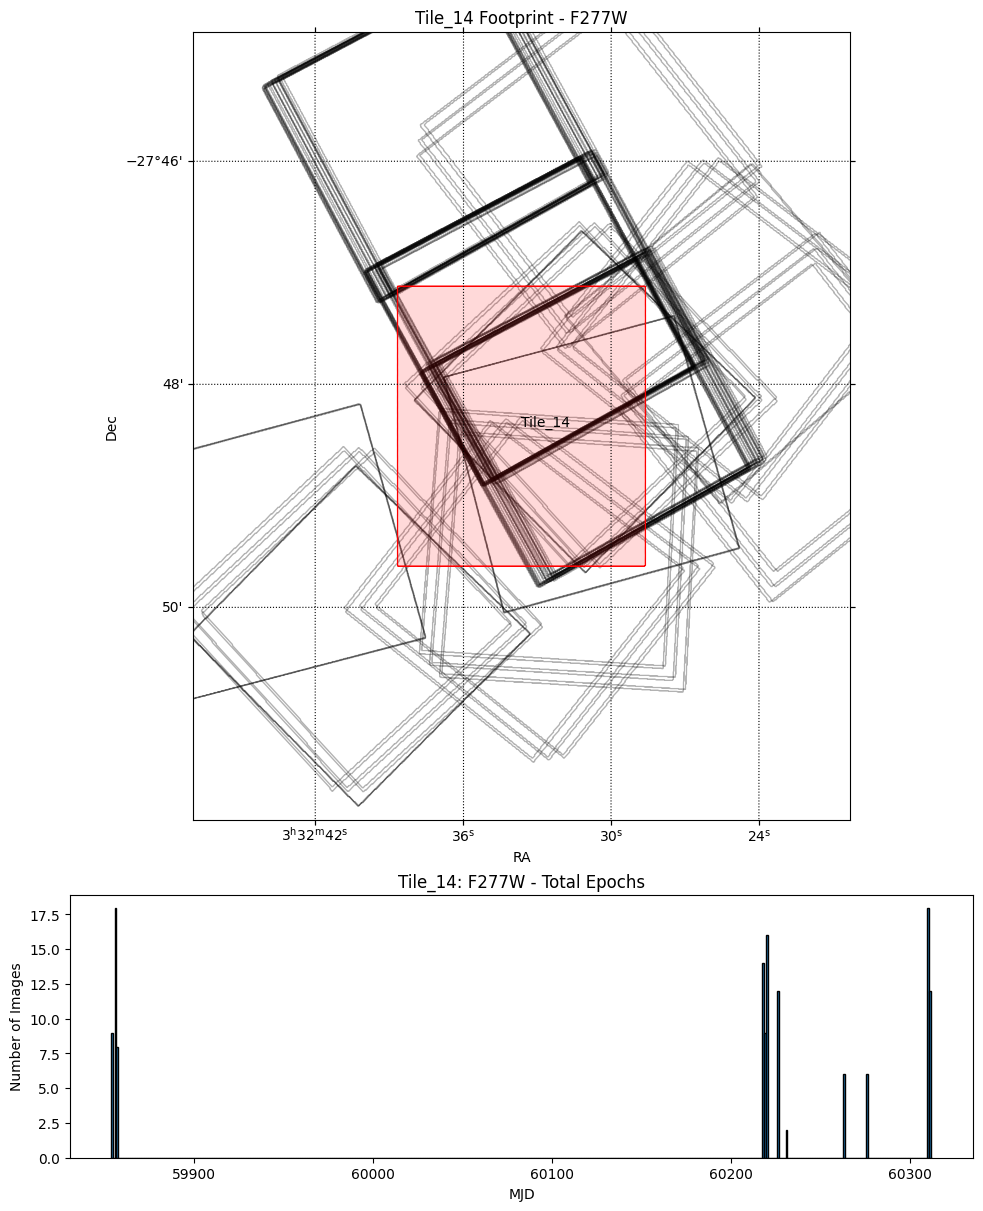

In [11]:
tile_id = 14 # Tile 1
# filter_tups = [(3, 'F200W')]
# filter_tups = [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W')]
# filter_tups = [(3, 'F200W'), (8, 'F444W')]
# filter_tups = [(8, 'F444W')]
filter_tups = [(5, 'F277W')]
viz.plot_tile_contents(image_dataframe=tile_image_dict[tile_id], tile_dataframe=tiles_df, filter_tuples=filter_tups, tile_id=tile_id, fov_scale=2.5)


In [12]:
do_save = True
distance_thresh = 10

# For tile, for filter -> grab epochs from the resulting image list
for tile_id, images_in_tile in tile_image_dict.items():
    
    for _band_id in images_in_tile["band_id"].unique():        
        
        in_band_images = images_in_tile[images_in_tile["band_id"] == _band_id]
        in_band_mjds = list(in_band_images.mjd_avg)
        epochs = DataUtils.CreateEpochsFromMJDs(in_band_mjds, peak_distance_thresh=distance_thresh)
        
        if do_save:
            data_repo.save_tile_epochs(start_mjds=epochs[:,0], end_mjds=epochs[:,1], tile_id=tile_id, band_id=_band_id, project_id=project_id)

Epoch exists for Project=`1`, Band=`8`, and Tile=`1` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`3`, and Tile=`1` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`8`, and Tile=`2` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`3`, and Tile=`2` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`13`, and Tile=`2` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`12`, and Tile=`2` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`8`, and Tile=`3` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`3`, and Tile=`3` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`13`, and Tile=`3` for MJDs:59891-59912.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`12`, and Tile=`3` for MJDs:59891-59912.
No unique ep

Epoch exists for Project=`1`, Band=`5`, and Tile=`9` for MJDs:59846-59867.
Epoch exists for Project=`1`, Band=`5`, and Tile=`9` for MJDs:60209-60230.
Epoch exists for Project=`1`, Band=`5`, and Tile=`9` for MJDs:60253-60274.
Epoch exists for Project=`1`, Band=`5`, and Tile=`9` for MJDs:60266-60287.
Epoch exists for Project=`1`, Band=`5`, and Tile=`9` for MJDs:60300-60321.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`7`, and Tile=`9` for MJDs:59847-59868.
Epoch exists for Project=`1`, Band=`7`, and Tile=`9` for MJDs:60210-60231.
Epoch exists for Project=`1`, Band=`7`, and Tile=`9` for MJDs:60253-60274.
Epoch exists for Project=`1`, Band=`7`, and Tile=`9` for MJDs:60300-60321.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`3`, and Tile=`9` for MJDs:59847-59868.
Epoch exists for Project=`1`, Band=`3`, and Tile=`9` for MJDs:60210-60231.
Epoch exists for Project=`1`, Band=`3`, and Tile=`9` for MJDs:60253-60274.
Epoch exists for Project=`1`, Band=`3`, and Tile

Epoch exists for Project=`1`, Band=`15`, and Tile=`13` for MJDs:59853-59874.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`10`, and Tile=`14` for MJDs:59845-59866.
Epoch exists for Project=`1`, Band=`10`, and Tile=`14` for MJDs:60212-60233.
Epoch exists for Project=`1`, Band=`10`, and Tile=`14` for MJDs:60253-60274.
Epoch exists for Project=`1`, Band=`10`, and Tile=`14` for MJDs:60301-60322.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`11`, and Tile=`14` for MJDs:59853-59874.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`9`, and Tile=`14` for MJDs:59846-59867.
Epoch exists for Project=`1`, Band=`9`, and Tile=`14` for MJDs:60210-60231.
Epoch exists for Project=`1`, Band=`9`, and Tile=`14` for MJDs:60253-60274.
Epoch exists for Project=`1`, Band=`9`, and Tile=`14` for MJDs:60300-60321.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`6`, and Tile=`14` for MJDs:59846-59867.
Epoch exists for Project=`1`, Band=`6`, and Tile=`14` 

Epoch exists for Project=`1`, Band=`10`, and Tile=`18` for MJDs:59845-59866.
Epoch exists for Project=`1`, Band=`10`, and Tile=`18` for MJDs:60211-60232.
Epoch exists for Project=`1`, Band=`10`, and Tile=`18` for MJDs:60301-60322.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`1`, and Tile=`18` for MJDs:59845-59866.
Epoch exists for Project=`1`, Band=`1`, and Tile=`18` for MJDs:60209-60230.
Epoch exists for Project=`1`, Band=`1`, and Tile=`18` for MJDs:60216-60237.
Epoch exists for Project=`1`, Band=`1`, and Tile=`18` for MJDs:60266-60287.
Epoch exists for Project=`1`, Band=`1`, and Tile=`18` for MJDs:60301-60322.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`11`, and Tile=`18` for MJDs:59853-59874.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`5`, and Tile=`18` for MJDs:59846-59867.
Epoch exists for Project=`1`, Band=`5`, and Tile=`18` for MJDs:60209-60230.
Epoch exists for Project=`1`, Band=`5`, and Tile=`18` for MJDs:60217-60238.
Epoch 

Epoch exists for Project=`1`, Band=`7`, and Tile=`22` for MJDs:60216-60237.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`1`, and Tile=`22` for MJDs:60216-60237.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`10`, and Tile=`22` for MJDs:60216-60237.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`2`, and Tile=`22` for MJDs:60216-60237.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`5`, and Tile=`22` for MJDs:60216-60237.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`3`, and Tile=`22` for MJDs:60216-60237.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`9`, and Tile=`23` for MJDs:59846-59867.
Epoch exists for Project=`1`, Band=`9`, and Tile=`23` for MJDs:60210-60231.
No unique epochs to save!
Epoch exists for Project=`1`, Band=`1`, and Tile=`23` for MJDs:59845-59866.
Epoch exists for Project=`1`, Band=`1`, and Tile=`23` for MJDs:60210-60231.
No unique epochs to save!
Epoch exists for Project=`1`, B

In [95]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
sys.path.append("/Users/mgriggio/diffpype/src/steps")
import Executors
import OneOverF
import BkgSub
import Mosaic
import importlib
importlib.reload(OneOverF)
importlib.reload(Executors)
importlib.reload(BkgSub)
importlib.reload(Mosaic)


lvl2_cal = tile_image_dict[14][tile_image_dict[14].band_id == 5]

# 1overf
inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'rawimage'])
outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/1overf'])

with Executors.Executor(kind='local').ex as executor:
    futures = [executor.submit(OneOverF.oneoverf, lvl2.base_filename.split('.')[0], lvl2.current_file_ext, lvl2.lvl2_id, inpdir, outdir, logdir) for lvl2 in lvl2_cal]

err = False
for future in as_completed(futures):
    res = future.result()
    if(isinstance(res, tuple)):
        if(res[0] != 0):
            print('An error occurred, check the logs for '+lvl2_df[lvl2_df.lvl_id == res[1]].iloc[0].base_filename)
            err = True
            continue

        idx = lvl2_df.index[lvl2_df.lvl_id == res[1]]
        lvl2_df.at[idx, 'lvl2cal_status_id'] = 3
        lvl2_df.at[idx, 'current_file_ext'] = res[2]
    
    else:
        print('An error occurred: '+str(res))
        err = True

if(err == False):
    lvl2_df = data_repo.save_lvl2_cals(lvl2_df)

# skymatch
inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/skymatch'])

with Executors.Executor(kind='local').ex as executor:
    futures = [executor.submit(BkgSub.subtract_background, lvl2.base_filename.split('.')[0], lvl2.current_file_ext, lvl2.lvl2_id, inpdir, outdir, logdir) for lvl2 in lvl2_cal]

err = False
for future in as_completed(futures):
    res = future.result()
    if(isinstance(res, tuple)):
        if(res[0] != 0):
            print('An error occurred, check the logs for '+lvl2_df[lvl2_df.lvl_id == res[1]].iloc[0].base_filename)
            err = True
            continue

        idx = lvl2_df.index[lvl2_df.lvl_id == res[1]]
        lvl2_df.at[idx, 'lvl2cal_status_id'] = 4
        lvl2_df.at[idx, 'current_file_ext'] = res[2]
    
    else:
        print('An error occurred: '+str(res))
        err = True

if(err == False):
    lvl2_df = data_repo.save_lvl2_cals(lvl2_df)
    
# # mosaic        
# inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
# outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
# logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/mosaic/'])

# mosaic_out = 'test_mosaic'
# # CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape
# tile_params = (25, 25, 53.13211333333333, -27.7968077777777, 0.060, 0, (50, 50))

# Mosaic.create_mosaic([lvl2_filename.replace('.fits','_1overf_skymatch.fits') for lvl2_filename in lvl2_cal], mosaic_out, inpdir, outdir, logdir, tile_params)


AttributeError: 'str' object has no attribute 'base_filename'

2025-07-21 11:13:56,398 - stpipe - WARNING - /Users/mgriggio/diffpype/src/workflow_manager/visualization.py:226: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig("%s/%s_%s_%s_%s_footprint.png" % (self.image_dir, tile_name, start_mjd, stop_mjd, filt_name),

2025-07-21 11:13:58,153 - stpipe - WARNING - /Users/mgriggio/diffpype/src/workflow_manager/visualization.py:226: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig("%s/%s_%s_%s_%s_footprint.png" % (self.image_dir, tile_name, start_mjd, stop_mjd, filt_name),

2025-07-21 11:14:00,974 - stpipe - WARNING - /opt/miniconda3/envs/new_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, 

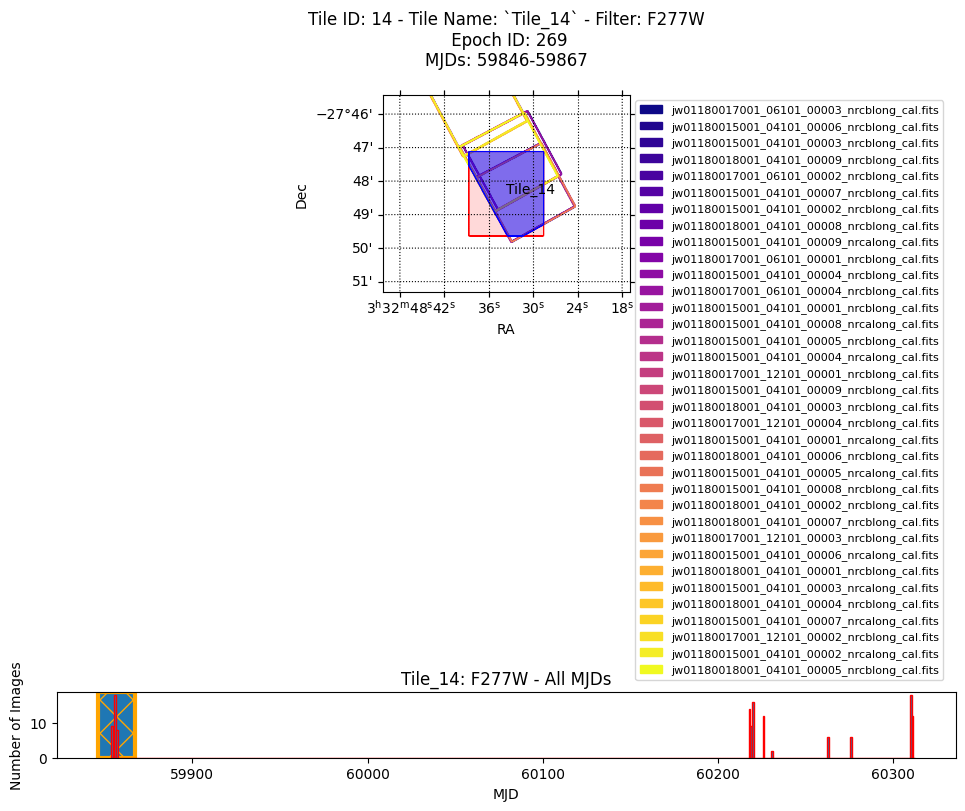

2025-07-21 11:14:01,831 - stpipe - WARNING - /opt/miniconda3/envs/new_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)

2025-07-21 11:14:01,850 - stpipe - WARNING - /opt/miniconda3/envs/new_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)



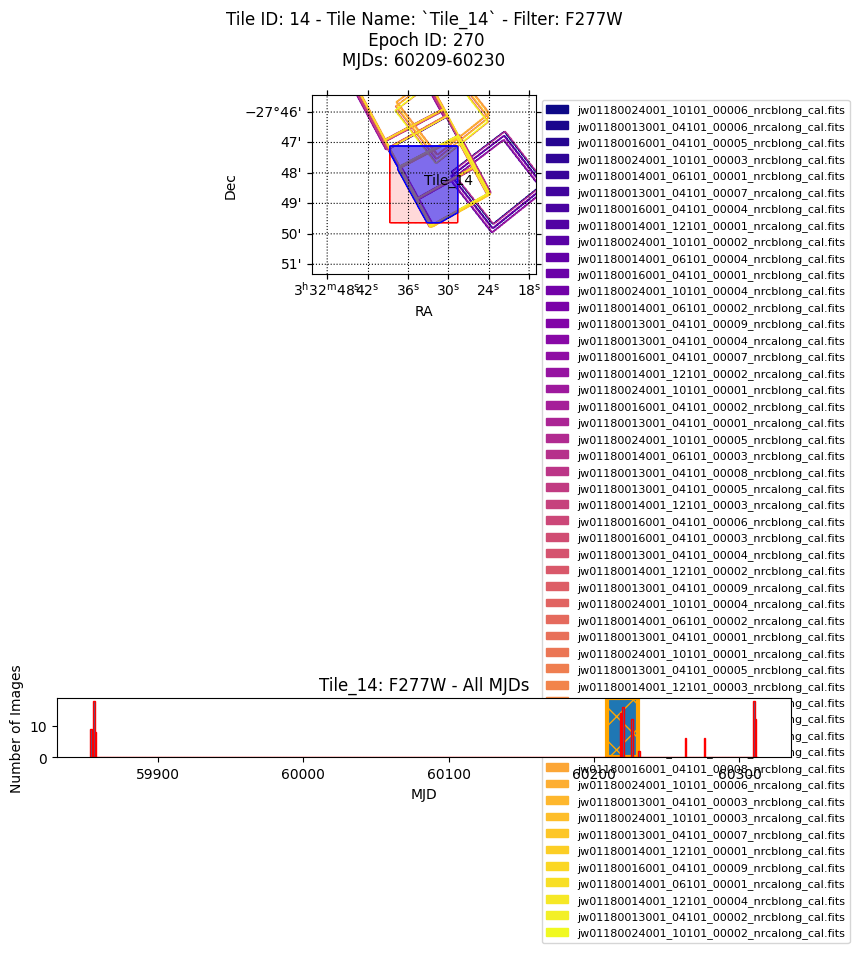

2025-07-21 11:14:02,062 - stpipe - WARNING - /opt/miniconda3/envs/new_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)

2025-07-21 11:14:02,081 - stpipe - WARNING - /opt/miniconda3/envs/new_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)



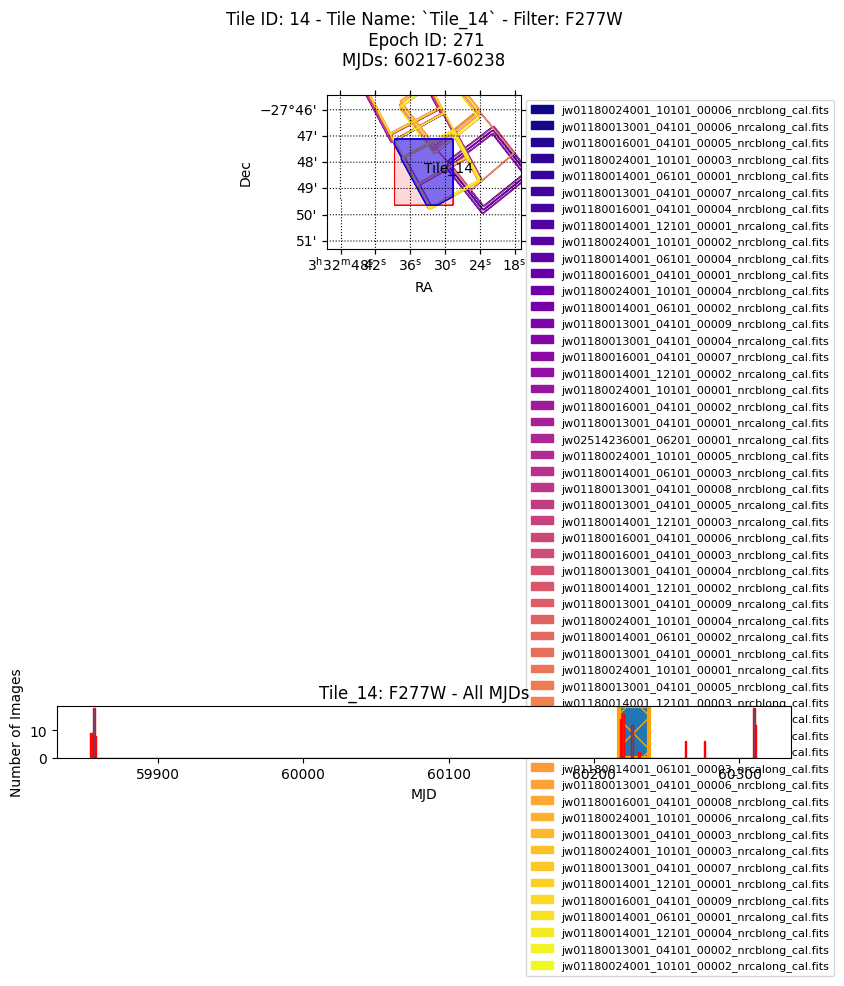

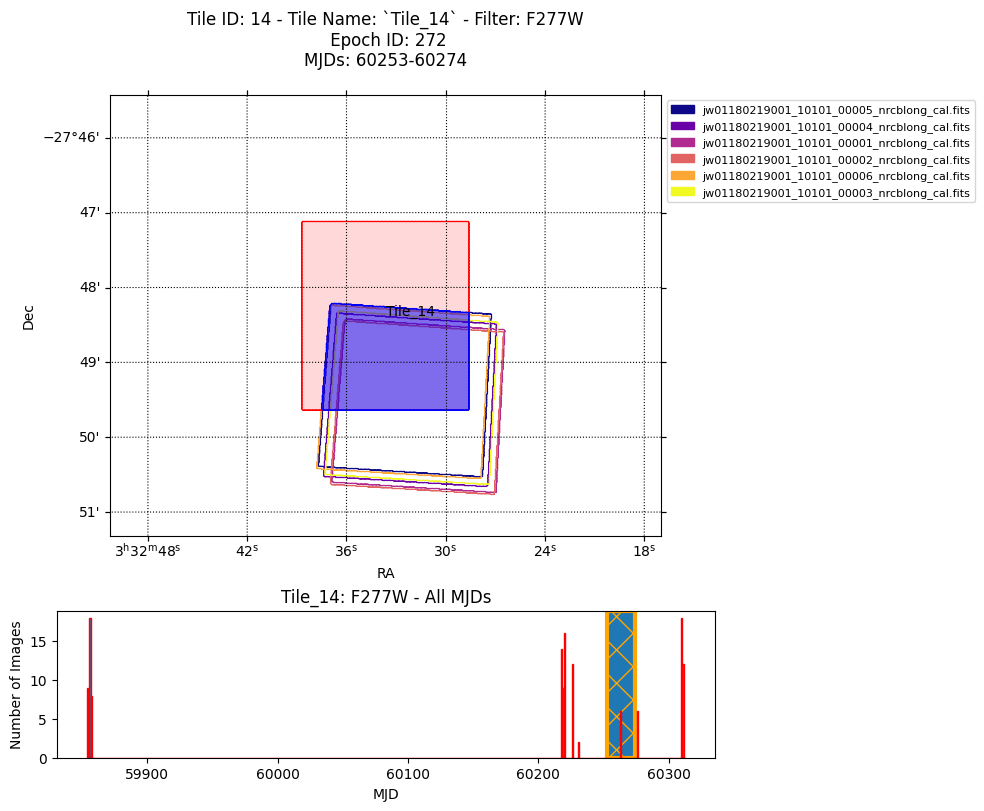

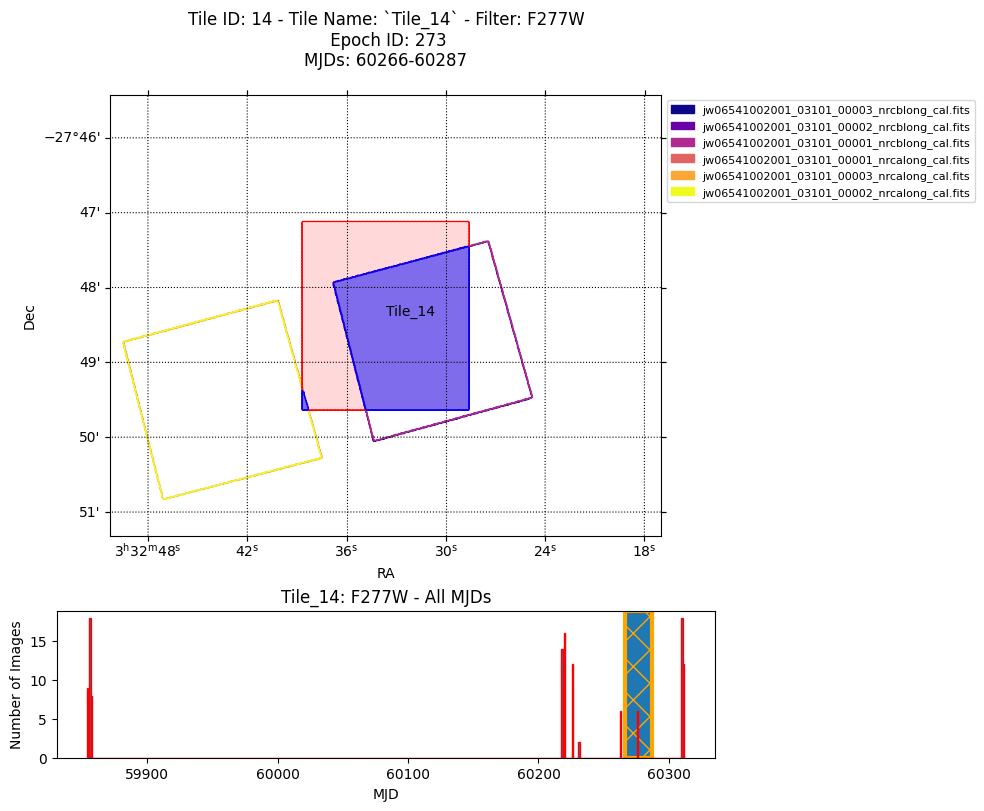

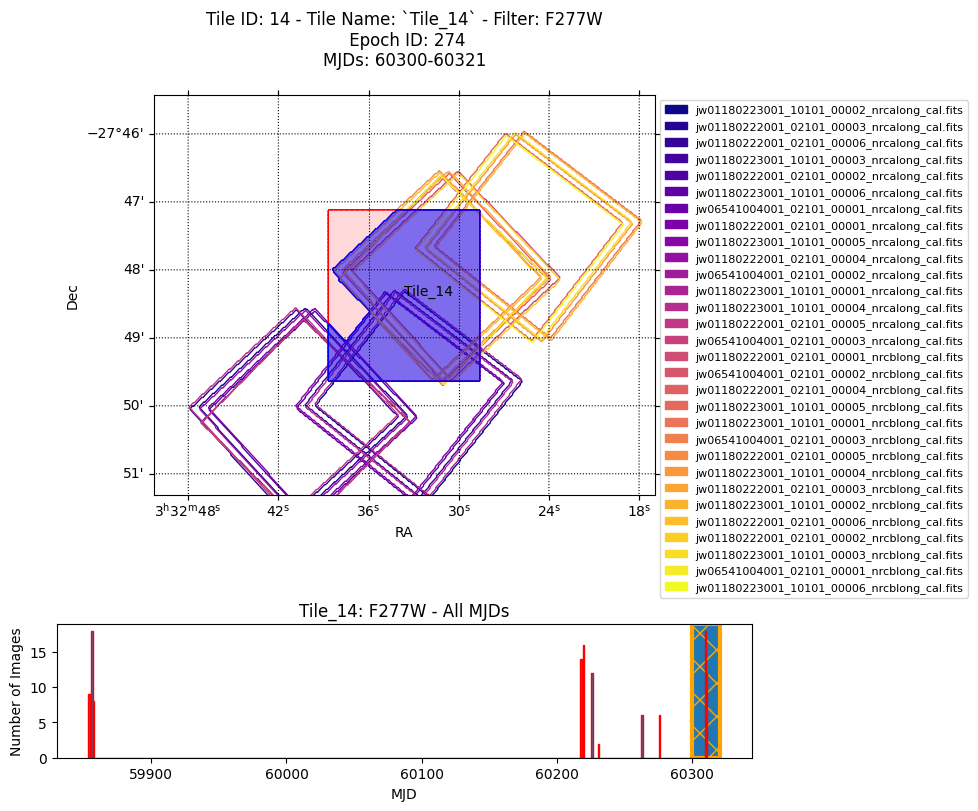

In [12]:
# Plot any combination of tile and band
_tile_id = 14
_tile_filter_tuple = (5, 'F277W')
# _tile_id = 17
# _tile_filter_tuple = (1, 'F115W')

# _tile_filter_tuple = (8, 'F444W')


_tile_df = tiles_df[tiles_df["id"] == _tile_id]
_tile_obj = _tile_df.iloc[0]
_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=_tile_id, band_id=_tile_filter_tuple[0], project_id=project_id)
_tile_img_df = tile_image_dict[_tile_id]

for _tp_index, _tp in _tile_epochs.iterrows(): 
    _ep_start = _tp["start_mjd"]
    _ep_stop = _tp["end_mjd"]
    
    _in_epoch_imgs = _tile_img_df[(_tile_img_df.mjd_avg >= _ep_start) & (_tile_img_df.mjd_avg <= _ep_stop) & (_tile_img_df.band_id == _tile_filter_tuple[0])]
    
    viz.plot_epochs(all_image_dataframe=_tile_img_df, epoch_image_dataframe=_in_epoch_imgs, tile_dataframe=tiles_df, filter_tuple=_tile_filter_tuple, tile_id=_tile_id, fov_scale=2.5, epoch_record=_tp)
    
    # break

In [ ]:
# poly = lvl3_moc.get_boundaries()
lvl2_df = tile_image_dict[1]

lvl3_moc = DataUtils.Get_Unioned_MOC(list(lvl2_df.moc))

print(lvl3_moc.get_boundaries())




# I need to figure out if this is a good way to generate the polygon from the unioned moc object. It's not necessary for the mosaic, but it is necessary for visualizing the footprint before generating it.

In [ ]:
# Save tile-epoch-lvl2 => mosaic
# We have to create a lvl3 record, and then use the ID to create the lvl2->lvl3 lookup table to create the mosaic
#   Mosaic = Tile ID, Band ID, Epoch ID  

# Iterate over all tiles
#   Over all unique bands
#       Over all enclosed images by band
#       Group by epoch
#           Save unique combo of tile_id, band_id, image_id, epoch_id
for tile_id, lvl2_in_tile in tile_image_dict.items():
    
    for band_id in lvl2_in_tile["band_id"].unique():
        in_band_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=tile_id, band_id=band_id, project_id=project_id)
        
        
        for index, epoch in in_band_tile_epochs.iterrows():

            # Create lvl2-epoch records
            start_mjd = epoch["start_mjd"]
            end_mjd = epoch["end_mjd"]
            epoch_id = epoch["id"]
            in_epoch_lvl2 = lvl2_in_tile[(lvl2_in_tile.mjd_avg >= start_mjd) & (lvl2_in_tile.mjd_avg <= end_mjd) & (lvl2_in_tile.band_id == band_id)]
            
            lvl2_epoch_assc = data_repo.save_epoch_lvl2cal_association(epoch_id, in_epoch_lvl2)
            
            # Create lvl3mosaic obj
            lvl3mosaic = data_repo.save_lvl3mosaic(project_id, tile_id, band_id, epoch_id, in_epoch_lvl2)
            
            
            
            
        


In [ ]:
# # Save Epochs
# epoch_dataframe = data_repo.save_tile_epochs(start_mjds=[f444w_epoch_1_start, f444w_epoch_2_start], 
#                            end_mjds=[f444w_epoch_1_end, f444w_epoch_2_end], tile_id=tile_id, project_id=project_id)
# # epoch_dataframe = data_repo.retrieve_tile_epochs(tile_id=tile_id, project_id=project_id)
# print(epoch_dataframe)

In [ ]:
# test = "2023-01-02 00:00:00.000000"
# test2 = Time(test).mjd
# print(test2)

In [ ]:
# in_epoch1_f200w_imgs.info()

In [ ]:
class StepStatus(Enum):
    NotStarted = 0
    InProcess = 1
    Complete = 2
    Error = 3

class Step(Enum):
    OneOverF = 0
    Mosaic = 1

class Image:
    def __init__(self, file_path):
        # ingest file

        h_sci = fits.getheader(file_path,'SCI')
        h_pri = fits.getheader(file_path,'PRIMARY')
    
        f_wcs = WCS(h_sci)
        self.coord = SkyCoord(float(h_sci["CRVAL1"]), float(h_sci["CRVAL2"]), unit="deg", frame="icrs")
        self.poly = f_wcs.calc_footprint()
        skycoord = SkyCoord(self.poly, unit="deg", frame="icrs")
        self.moc = MOC.from_polygon_skycoord(skycoord, complement=False, max_depth=21)

        mjd_avg = float(h_sci["MJD-AVG"])
        self.mjd = mjd_avg
        self.obs_date = Time(mjd_avg, format='mjd')
        self.filt = h_pri["FILTER"]

raw_images = [Image(os.path.join(base_path, img_path)) for img_path in all_mast_files[0:1000]]

pprint(all_mast_files[0:10])

image_dict = {}
for img in raw_images:
    if img.filt not in image_dict:
        image_dict[img.filt] = []
    image_dict[img.filt].append(img)

print(list(image_dict.keys()))


# work_tables = {
#     'Image':[]
# }

# step_parameters = {
#     Step.OneOverF = {},
#     Step.Mosaic = {}
# }






# class PypeStep(metaclass=ABCMeta):

#     def __init__(self, name: str, executable_func: callable, func_settings: dict = None, func_args: list = None)
#         self.name = name
#         self.executable_func = executable_func

        

#     @property
#     @abstractmethod
#     def depends_on(self):
#         raise NotImplementedError

#     @abstractmethod
#     def run(self):
#         raise NotImplementedError

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

filter_to_process = 'F115W'
# filter_to_process = 'F277W'
in_filter_imgs = image_dict[filter_to_process]
print("Num images in filter %s: %s" % (filter_to_process, len(in_filter_imgs)))

mjds = np.asarray([img.mjd for img in in_filter_imgs])

start = int(np.floor(np.min(mjds)))
end = int(np.ceil(np.max(mjds)))
num_bins = (end - start)+2
bins = np.linspace(start, end + 1, num_bins)

_bins = ax.hist(mjds, bins=bins)
ax.ticklabel_format(useOffset=False, style='plain')
ax.set_ylabel('Number of Images')
ax.set_xlabel('MJD')

In [ ]:
%time

union_moc = in_filter_imgs[0].moc
for img in in_filter_imgs:
    union_moc = union_moc.union(img.moc)

covered_area = union_moc.sky_fraction*41253
fov_proxy = 2*np.sqrt(covered_area)

bary = union_moc.barycenter()

fig = plt.figure(111, figsize=(10, 10))
with mocWCS(
    fig,
    fov=fov_proxy * u.degree,
    center=bary,
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    # The gnomonic projection transforms great circles into straight lines.
    projection="TAN",
) as _wcs:
    ax = fig.add_subplot(1, 1, 1, projection=_wcs)
    # Call fill with a matplotlib axe and the `~astropy.wcs.WCS` wcs object.

    for img in in_filter_imgs:
        # img.moc.fill(ax=ax, wcs=_wcs, alpha=0.5, fill=True, linewidth=1)
        img.moc.border(ax=ax, wcs=_wcs, alpha=0.3)

plt.xlabel("RA")
plt.ylabel("Dec")
plt.title("%s Pointings" % filter_to_process)
plt.grid(color="black", linestyle="dotted")
plt.show()

In [ ]:
class OneOverF(PypeStep):

    def __init__(self, input_file):
        self.input_file = input_file
        self.status = StepStatus.NotStarted

    @property
    def depends_on(self):
        return None

    def run(self):
        with fits.open(self.input_file) as cal2hdulist:
            # what if this condition is not true? we can't do 1overf?
            if cal2hdulist['PRIMARY'].header['SUBARRAY']=='FULL' or cal2hdulist['PRIMARY'].header['SUBARRAY']=='SUB256':
                
                sigma_bgmask=3.0
                sigma_1fmask=2.0
                splitamps=False   # Set to True only in a sparse field so each amplifier will be fit separately.
                
                correcteddata = sub1fimaging(cal2hdulist, sigma_bgmask, sigma_1fmask, splitamps)
                
                if cal2hdulist['PRIMARY'].header['SUBARRAY']=='FULL':
                    cal2hdulist['SCI'].data[4:2044,4:2044] = correcteddata
                elif cal2hdulist['PRIMARY'].header['SUBARRAY']=='SUB256':
                    cal2hdulist['SCI'].data[:252,:252] = correcteddata
                
                cal2hdulist.writeto(input_image.split(".")[0]+"_1overf.fits", overwrite=True)
            else:
                raise Exception("Can't perform 1 over f correction")
    

In [ ]:
class CreateMosiac(PypeStep):

    def __init__(self, input_file):
        self.input_file = input_file
        self.status = StepStatus.NotStarted

    @property
    def depends_on(self):
        return None

    def run(self):
        flt = asn.split('.')[0].split('_')[-1]

        pxsc = 0.060
        
        if(flt == "F115W" or flt == "F150W" or flt == "F200W"):
            pxsc = 0.030
    
    
        pipe3 = Image3Pipeline()
        pipe3.step_defs["skymatch"] = DavesBBSkyMatchStep
        
        # we have to check these too
        params = {
    
                'skymatch': {
                                'skip': False,
                                'skymethod': 'local',
                                'subtract': True,
                                'skystat': 'median',
                                'usigma': 3,
                                'lsigma': 3,
                                'nclip': 5
                            },
                'resample': {
                                'pixfrac': 1.,
                                'kernel': 'square',
                                'fillval': 'indef',
                                'weight_type': 'ivm',
                                'in_memory': True,
                                'save_results': True
                            }
                }
    
    
    
    
        # these come from the tile definition
        CRPIX1 = 250
        CRPIX2 = 250
        CRVAL1 = ra
        CRVAL2 = dec
        params['resample']['pixel_scale'] = pxsc
        params['resample']['rotation'] = 0
        params['resample']['output_shape'] = [500,500]
        
        params['resample']['crpix'] = [CRPIX1,CRPIX2]
        params['resample']['crval'] = [CRVAL1,CRVAL2]
    
    
        pipe3.call(asn, steps=params, output_dir=out_dir,
            save_results=True)

In [ ]:
import math


def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx
    
northern_limit = 89.99999
southern_limit = -89.99999
eastern_limit = 359.99999
western_limit = 0.0

# northern_limit = 2.45
# southern_limit = 2.25
# eastern_limit = 150.0166666667
# western_limit = 150.0003333333

dec_range = 179.99999
ra_range = 359.99999
# dec_range = northern_limit-southern_limit
# ra_range = eastern_limit-western_limit
# print(dec_range, ra_range)

deg_height = 2.75/60.0 # 
deg_width = 2.75/60.0 # 

frac_dec_tile, num_dec_tiles = math.modf(dec_range / deg_height)

total_dec_tiles = int(num_dec_tiles) + 1
if num_dec_tiles == 0:
    num_dec_tiles = 1

dec_differential = (deg_height - (frac_dec_tile * deg_height)) / num_dec_tiles

dec_delta = deg_height - dec_differential
starting_dec = southern_limit + deg_height / 2.0

decs = []
for i in range(total_dec_tiles):
    d = starting_dec + i * dec_delta
    decs.append(d)

ras_over_decs = []
for d in decs:

    adjusted_tile_width = deg_width / np.abs(np.cos(np.radians(d)))

    frac_ra_tile, num_ra_tiles = math.modf(ra_range / adjusted_tile_width)
    total_ra_tiles = int(num_ra_tiles) + 1

    if num_ra_tiles == 0:
        num_ra_tiles = 1

    ra_differential = (adjusted_tile_width - (frac_ra_tile * adjusted_tile_width)) / num_ra_tiles
    ra_delta = adjusted_tile_width - ra_differential

    ras = []
    starting_ra = adjusted_tile_width / 2.0
    for i in range(total_ra_tiles):
        r = starting_ra + i * ra_delta
        ras.append(r)

    ras_over_decs.append(ras)

print("All Sky statistics")
print("\tNum of dec strips: %s" % len(decs))

north_index = find_nearest(decs, northern_limit)
south_index = find_nearest(decs, southern_limit)
equator_index = find_nearest(decs, 0.0)

print("\tNorthern most dec: %s" % decs[north_index])
print("\tSouthern most dec: %s" % decs[south_index])

east_index = find_nearest(ras_over_decs[equator_index], eastern_limit)
west_index = find_nearest(ras_over_decs[equator_index], western_limit)

print("\tEastern most ra: %s" % ras_over_decs[equator_index][east_index])
print("\tWestern most ra: %s" % ras_over_decs[equator_index][west_index])

print("\tNum of ra tiles in northern most dec slice: %s" % len(ras_over_decs[north_index]))
print("\tNum of ra tiles at celestial equator: %s" % len(ras_over_decs[equator_index]))

print("Constructing grid of coordinates...")
RA = []
DEC = []
for i, d in enumerate(decs):
    for ra in ras_over_decs[i]:

        if ra <= 151.0 and ra >= 150.0 and d <= 2.5 and d >= 2.0:
            RA.append(ra)
            DEC.append(d)

all_sky = list(zip(RA, DEC))
print(len(all_sky))
all_sky_coords = SkyCoord(RA, DEC, unit=(u.degree, u.degree), frame="icrs")


In [ ]:
%time
tile_index = 10

close = all_sky_coords.separation(bary).degree < fov_proxy/1.75
# print(close)

close_coords = all_sky_coords[close]
print(len(close_coords))

deg_height = 3.0/60.0 # 3 arcminutes
deg_width = 3.0/60.0 # 3 arcminutes

x_step = deg_width / 2.0
y_step = deg_height / 2.0

tiles_mocs = []
for c in close_coords:

    _ras = np.asarray([c.ra.degree+x_step, c.ra.degree+x_step, c.ra.degree-x_step, c.ra.degree-x_step])
    _decs = np.asarray([c.dec.degree+y_step, c.dec.degree-y_step, c.dec.degree-y_step, c.dec.degree+y_step])
    _p = SkyCoord(_ras, _decs, unit="deg", frame="icrs")
    tiles_mocs.append(MOC.from_polygon_skycoord(_p, complement=False, max_depth=21))


fig = plt.figure(111, figsize=(10, 10))

with mocWCS(
    fig,
    fov=fov_proxy * u.degree,
    center=bary,
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    # The gnomonic projection transforms great circles into straight lines.
    projection="TAN",
) as _wcs:
    ax = fig.add_subplot(1, 1, 1, projection=_wcs)
    # Call fill with a matplotlib axe and the `~astropy.wcs.WCS` wcs object.

    for img in in_filter_imgs:
        # img.moc.fill(ax=ax, wcs=_wcs, alpha=0.5, fill=True, linewidth=1)
        img.moc.border(ax=ax, wcs=_wcs, alpha=0.3)

    
    for i, tm in enumerate(tiles_mocs):
        clr = 'red'
        if i == tile_index:
            clr = 'blue'
        
            
        tm.border(ax=ax, wcs=_wcs, alpha=1.0, color=clr)
        tm.fill(ax=ax, wcs=_wcs, alpha=0.15, fill=True, linewidth=0, color=clr)

        c = close_coords[i]
        # ax.plot(c.ra.degree, c.dec.degree, 'x', color="blue", markersize=1, transform=ax.get_transform("world"))
        ax.text(c.ra.degree, c.dec.degree, "Tile %s" % (i), transform=ax.get_transform("world"))

# northern_limit = 2.45
# southern_limit = 2.25
# eastern_limit = 150.0166666667
# western_limit = 150.0003333333
# ax.set_xlim([150, 151])

plt.xlabel("RA")
plt.ylabel("Dec")
plt.title("%s Pointings" % filter_to_process)
plt.grid(color="black", linestyle="dotted")
plt.show()

In [ ]:
tile_to_get = tiles_mocs[tile_index]
c = close_coords[tile_index]

overlapping = []
for img in in_filter_imgs:
    if np.any(tile_to_get.contains_lonlat(img.poly[:, 0]*u.degree, img.poly[:, 1]*u.degree)):
        overlapping.append(img)

fig = plt.figure(111, figsize=(10, 10))
with mocWCS(
    fig,
    fov=5/60. * u.degree,
    center=c,
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    # The gnomonic projection transforms great circles into straight lines.
    projection="TAN",
) as _wcs:
    ax = fig.add_subplot(1, 1, 1, projection=_wcs)
    # Call fill with a matplotlib axe and the `~astropy.wcs.WCS` wcs object.

    for img in overlapping:
        img.moc.border(ax=ax, wcs=_wcs, alpha=0.3)

    
    tile_to_get.border(ax=ax, wcs=_wcs, alpha=1.0, color="blue")
    tile_to_get.fill(ax=ax, wcs=_wcs, alpha=0.15, fill=True, linewidth=0, color="blue")

    
    ax.text(c.ra.degree, c.dec.degree, "Tile %s" % (tile_index), transform=ax.get_transform("world"))


In [ ]:
epoch_start = 60400
epoch_end = 60500

fig, ax = plt.subplots(figsize=(10,5))

mjds = np.asarray([img.mjd for img in overlapping])

start = int(np.floor(np.min(mjds)))
end = int(np.ceil(np.max(mjds)))
num_bins = (end - start)+2
bins = np.linspace(start, end + 1, num_bins)

_bins = ax.hist(mjds, bins=bins)

ax.axvspan(epoch_start, epoch_end, alpha=0.15, color='blue')

ax.ticklabel_format(useOffset=False, style='plain')
ax.set_ylabel('Number of Images')
ax.set_xlabel('MJD')

In [ ]:


mosaic_list = []
for img in overlapping:
    if img.mjd >= epoch_start and img.mjd <= epoch_end:
        mosaic_list.append(img)

fig = plt.figure(111, figsize=(10, 10))
with mocWCS(
    fig,
    fov=5/60. * u.degree,
    center=c,
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    # The gnomonic projection transforms great circles into straight lines.
    projection="TAN",
) as _wcs:
    ax = fig.add_subplot(1, 1, 1, projection=_wcs)
    # Call fill with a matplotlib axe and the `~astropy.wcs.WCS` wcs object.

    for img in mosaic_list:
        img.moc.border(ax=ax, wcs=_wcs, alpha=0.3)

    
    tile_to_get.border(ax=ax, wcs=_wcs, alpha=1.0, color="blue")
    tile_to_get.fill(ax=ax, wcs=_wcs, alpha=0.15, fill=True, linewidth=0, color="blue")

    
    ax.text(c.ra.degree, c.dec.degree, "Tile %s" % (tile_index), transform=ax.get_transform("world"))


In [ ]:



fig, ax = plt.subplots(figsize=(10,5))

mjds = np.asarray([img.mjd for img in mosaic_list])

start = int(np.floor(np.min(mjds)))
end = int(np.ceil(np.max(mjds)))
num_bins = (end - start)+2
bins = np.linspace(start, end + 1, num_bins)

_bins = ax.hist(mjds, bins=bins)
ax.ticklabel_format(useOffset=False, style='plain')
ax.set_ylabel('Number of Images')
ax.set_xlabel('MJD')

In [ ]:
    from sklearn.cluster import KMeans
    from scipy.signal import find_peaks
    
    plt.figure(dpi=300, figsize=(10, 3))
    
    
    mjd = np.array(image_df.mjd_avg)
    mjd_reshaped = mjd.reshape(-1, 1)
    
    
    start = int(np.floor(np.min(mjd)))
    end = int(np.ceil(np.max(mjd)))
    num_bins = (end - start) + 2
    bins = np.linspace(start, end + 1, num_bins)
    nbins = len(bins)
    
    hist, bin_edges = np.histogram(mjd, bins=nbins, range=[mjd.min()-1, mjd.max()+1])
    
    peak_distance_thresh = 10
    peaks, _ = find_peaks(hist, height=None, distance=peak_distance_thresh) # distance is the min spacing between histogram peaks before counting as a new peak
    total_peaks = len(peaks)
    print(total_peaks)
    
    # n clusters
    # k = 4
    
    kmeans = KMeans(n_clusters=total_peaks, random_state=0)
    kmeans.fit(mjd_reshaped)
    
    labels = kmeans.labels_
    
    bin_size = bin_edges[1] - bin_edges[0]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_indices = np.digitize(mjd, bin_edges, right=True)
    
    plt.subplot(121)
    
    plt.hist(mjd, bins=nbins, range=[mjd.min()-1, mjd.max()+1], color='darkslategrey')
    
    
    plt.subplot(122)
    
        
    cluster_centers = np.sort(kmeans.cluster_centers_.flatten())
    cluster_edges = (cluster_centers[:-1] + cluster_centers[1:]) / 2
    
    # print(cluster_centers)
    # print(cluster_edges)
    cluster_intervals = [(cc - peak_distance_thresh, cc + peak_distance_thresh) for cc in cluster_centers]
    print(cluster_centers)
    print(cluster_intervals)
    print(len(cluster_intervals))
    
    # for i in range(kmeans.n_clusters):
    for i in range(len(cluster_intervals)):
        
        mjd_i = mjd[labels==i]
        bins_i = bin_indices[labels==i]
        
        print(hist[bins_i - 1])
        plt.bar(bin_centers[bins_i - 1], hist[bins_i - 1], width=bin_size, color='C'+str(i))
        # plt.bar(cluster_intervals[i][0], hist[i], width=bin_size, color='C'+str(i))
    

In [ ]:
cols = ['hello', 'world']
print("This is '%s' " % ", ".join(cols))

In [ ]:
h_sci = fits.getheader('/Users/dcoulter/Code/notebooks/diffpype/ddt_9372/jw01727055001_02101_00001_nrca1_cal.fits', 'PRIMARY')
# f_wcs = WCS(h_sci)

In [ ]:
# test = json.dumps(f_wcs)
# print(type(test))
# print(f_wcs)
# 
# print(f_wcs['CTYPE'])

In [ ]:
cols = ['ra', 'decl', 'obs_start', 'exp_time', 'target_name', 'base_filename',
                'current_file_ext', 'filter', 'poly', 'instrument_name']
extra_cols = ['plate_scale', 'band_id', 'instrument_id', 'lvl2cal_id', 'lvl2cal_status_id']

all_cols = cols[:-1] +  extra_cols

print(all_cols)

all_cols.remove('band_id')

print(all_cols)

tuple(cols[:-1] +  extra_cols)


In [ ]:
# pprint(h_sci)

In [ ]:
test = "This %s a test %s, %s" % "is"
print(test)

In [ ]:
import copy
test = ['hello', 'world']

test2 = copy.deepcopy(test) 
test2.append('good bye')
test2.append('world')

print(test)
print(test2)

In [ ]:
mjd_list = [1, 2, 3, 4, 5, 6]

mjd = np.array(mjd_list)
mjd_reshaped = mjd.reshape(-1, 1)

start = int(np.floor(np.min(mjd)))
end = int(np.ceil(np.max(mjd)))

# set bins to daily
num_bins = (end - start) + 2
bins = np.linspace(start, end + 1, num_bins)
nbins = len(bins)

print(num_bins, nbins)
print(bins)

In [ ]:
sn1_poly_str = "POLYGON 150.160431166 2.355291744 150.127280667 2.369755527 150.141143546 2.402341359 150.174383362 2.388767403"
poly_str = "fk5\n" + sn1_poly_str
# poly_str = sn1_poly_str

print(poly_str)

In [ ]:
from regions import CircleSkyRegion, CirclePixelRegion, PolygonSkyRegion, Regions

In [ ]:
r = Regions.parse(poly_str, format='ds9')
print(r[0].vertices)
sn1_moc = MOC.from_polygon_skycoord(r[0].vertices, max_depth=20)
sn1_coord = SkyCoord(150.139013, 2.39575, unit=u.degree, frame="icrs")

In [ ]:
fig = plt.figure(111, figsize=(15, 15))

# Define a astropy WCS easily
with mocWCS(
    fig,
    fov=0.1*u.deg,
    center=sn1_coord,
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    # The gnomonic projection transforms great circles into straight lines.
    projection="TAN"
) as wcs:
    ax = fig.add_subplot(1, 1, 1, projection=wcs) # wcs

    sn1_moc.border(ax=ax, wcs=wcs, alpha=1.0, fill=False, color="blue", linewidth=2)
    
    ax.plot(sn1_coord.ra.degree, sn1_coord.dec.degree, "r+", label="SN 1", transform=ax.get_transform("world"))

    

plt.xlabel("ra")
plt.ylabel("dec")
plt.title("SN1")
plt.grid(color="black", linestyle="dotted")
plt.show()

In [ ]:
from shapely.geometry import Polygon

In [ ]:
# jwlist = dat[1].header['S_REGION'].split(' ')                
# jwlist = sn1_poly_str
# jw_reg = [float(i) for i in jwlist if i not in ['POLYGON','ICRS','']]
# jw_reg = [jw_reg[i:i+2] for i in range(0, len(jw_reg), 2)]



# sci_poly = Polygon(jw_reg)
# print(r[0].vertices)

poly_tuples = [(_r.ra.degree, _r.dec.degree) for _r in r[0].vertices]
sci_poly = Polygon(poly_tuples)
print(sci_poly)

In [ ]:
poly_tuples = [(150.160431166, 2.355291744), (150.127280667, 2.369755527), (150.141143546, 2.402341359), (150.174383362, 2.388767403), (150.160431166,2.355291744)]
sci_poly = Polygon(poly_tuples)
print(sci_poly)

In [ ]:
test = ['a', 'b', 'c']

test2, test3, test4 = test

In [ ]:
test2

In [ ]:
test3

In [ ]:
log10(Ms)=(7.5)

In [ ]:
log10(sSFR)=-8.25 = log10(SFR/Ms) = log10(SFR) - log10(Ms) -> log10(SFR) = -8.25+7.5

In [131]:
-8.25+7.5

-0.75